# ND2 Brain Section Pipeline

This notebook loads Nikon ND2 files, merges fluorescence channels into RGB, detects separated brain sections, and saves cropped section images.

## 1. Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
from PIL import Image

from brain_section_pipeline import (
    PipelineConfig,
    detect_section_crops,
    find_nd2_files,
    merge_channels,
    process_selected_files,
    read_nd2_image,
    select_nd2_files_dialog,
    summarize_nd2,
)

Image.MAX_IMAGE_PIXELS = None

## 2. Select ND2 Files

In [2]:
# Fast default: scan fallback_folder for ND2 files without opening a modal dialog.
# Set use_file_dialog=True only when you want to select files from a local dialog.
# If the dialog seems slow, check whether it is hidden behind VS Code, or interrupt the cell and keep this False.
use_file_dialog = False
fallback_folder = Path(r"R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610")
manual_selected_files = []  # Example: [r"D:\\data\\Slide_01_x4.nd2", r"D:\\data\\Slide_02_x4.nd2"]

if manual_selected_files:
    nd2_files = [Path(path) for path in manual_selected_files]
    input_folder = nd2_files[0].parent
elif use_file_dialog:
    nd2_files = select_nd2_files_dialog(initial_dir=fallback_folder)
    if not nd2_files:
        input_folder = fallback_folder
        nd2_files = find_nd2_files(input_folder, recursive=False)
    else:
        input_folder = nd2_files[0].parent
else:
    input_folder = fallback_folder
    nd2_files = find_nd2_files(input_folder, recursive=False)

output_folder = input_folder / "cropped_sections"

for index, path in enumerate(nd2_files):
    print(f"{index}: {path.name}")

0: Slide_01_x4.nd2
1: Slide_01_x4_GFP_9ms.nd2
2: Slide_02_x4.nd2
3: Slide_03_x4.nd2
4: Slide_04_x4.nd2
5: Slide_05_x4.nd2
6: Slide_06_x4.nd2
7: Slide_07_x4.nd2
8: Slide_08_x4.nd2
9: Slide_09_x4.nd2


## 3. Choose Files

In [3]:
# Leave selected_indices=None to process all files selected or discovered above.
# Set selected_indices=[0, 2] to process a subset from the printed list above.
selected_indices = [0, 2, 3, 4, 5, 6, 7, 8, 9]
selected_files = nd2_files if selected_indices is None else [nd2_files[index] for index in selected_indices]
selected_files

[WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_01_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_02_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_03_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_04_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_05_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_06_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_07_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_08_x4.nd2'),
 WindowsPath('R:/shared/data/AutoMaze/RM014/RM014_FTGO_NIKON_260610/Slide_09_x4.nd2')]

## 4. Configure Processing

In [4]:
config = PipelineConfig(
    # Demo ND2 metadata color order: channel 0 blue, channel 1 green, channel 2 orange/red.
    channel_colors=((3/255, 81/255, 1), (91/255, 1, 0), (1, 160/255, 0)),
    merge_channels=None,
    percentiles=(0.0, 100),
    # Rat demo data works best when tissue detection uses the blue channel, channel 0 in this ND2 metadata.
    # Set mask_channel=None to detect tissue from merged RGB intensity.
    mask_channel=0,
    min_area=1_000_000,
    margin=250,
    opening_radius=2,
    closing_iterations=160,
    # Options: "row_left_to_right", "row_right_to_left", "diagonal", "area".
    # Use row_right_to_left when section 1 should start at the upper right.
    sort_mode="row_right_to_left",
    z_projection="max",
    output_extension="tif",
    # Primary section*.tif outputs are direct RGB packing: R=ch2, G=ch1, B=ch0.
    # This is not pseudo-color merging, so ImageJ RGB split can recover the original channels.
    crop_output_mode="rgb_direct",
    rgb_direct_channels=(2, 1, 0),
    # Set True only when you also want an extra CYX raw-stack copy per slide.
    save_raw_channel_crops=False,
)

# Use a downsampled image for preview on multi-GB whole-slide ND2 files.
preview_downsample = 16

## 5. Preview Selected Files

Preview: Slide_01_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_01_x4.nd2', 'sizes': {'C': 3, 'Y': 19800, 'X': 38700}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 19800, 38700], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 19800, 'unsigned', 1, 232200, 38700, None, None, None, None, 3]}


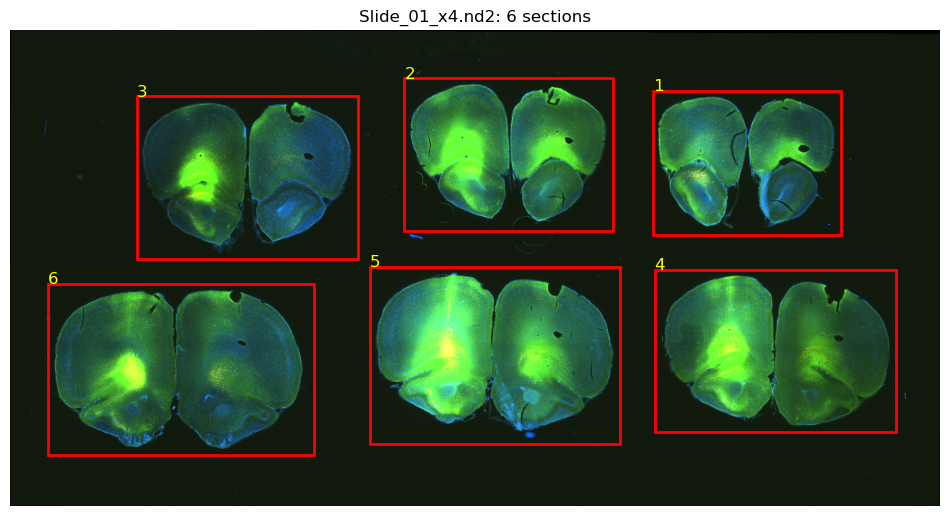

Detected sections: 6
Preview: Slide_02_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_02_x4.nd2', 'sizes': {'C': 3, 'Y': 19800, 'X': 44775}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 19800, 44775], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 19800, 'unsigned', 1, 268652, 44775, None, None, None, None, 3]}


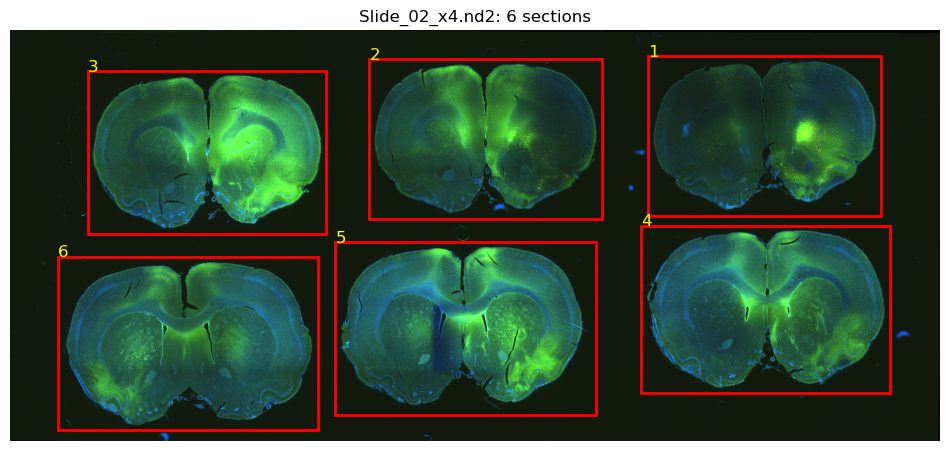

Detected sections: 6
Preview: Slide_03_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_03_x4.nd2', 'sizes': {'C': 3, 'Y': 26280, 'X': 46800}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 26280, 46800], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 26280, 'unsigned', 1, 280800, 46800, None, None, None, None, 3]}


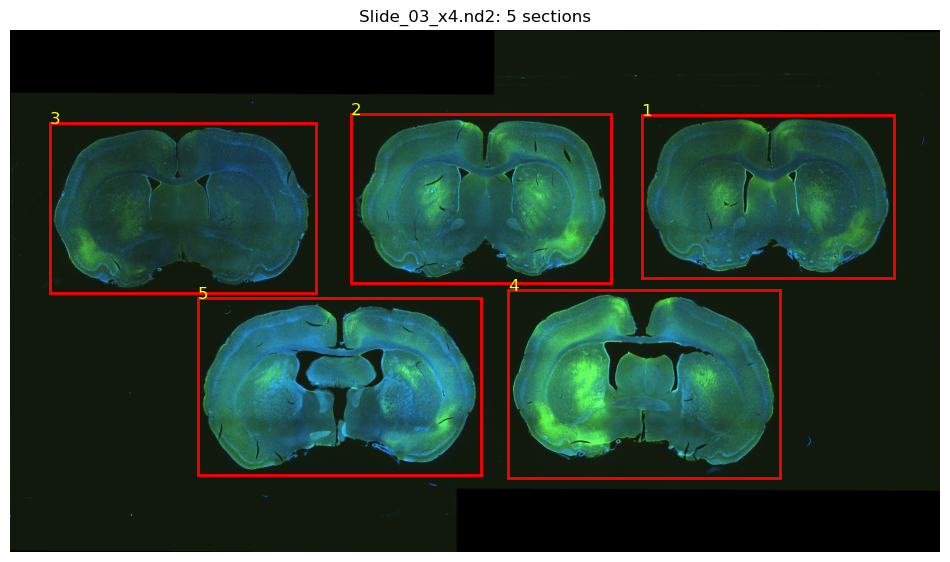

Detected sections: 5
Preview: Slide_04_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_04_x4.nd2', 'sizes': {'C': 3, 'Y': 23040, 'X': 44775}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 23040, 44775], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 23040, 'unsigned', 1, 268652, 44775, None, None, None, None, 3]}


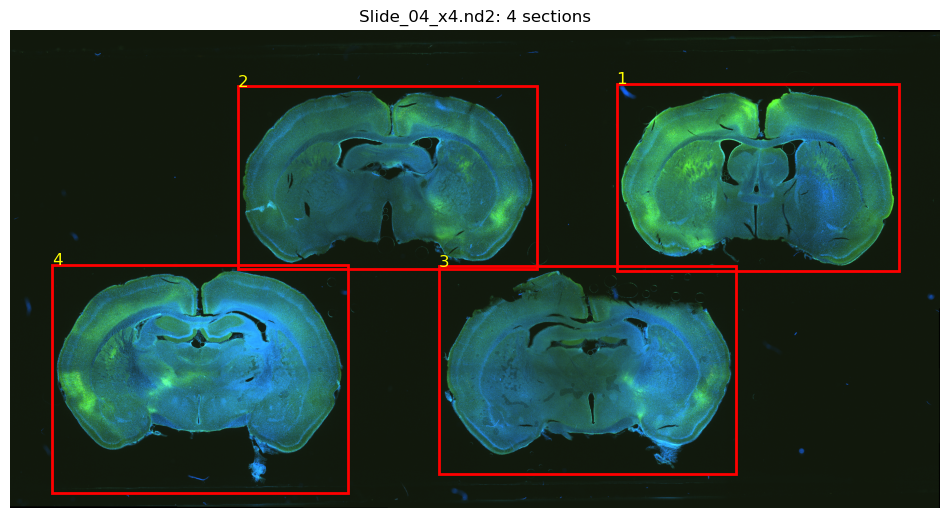

Detected sections: 4
Preview: Slide_05_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_05_x4.nd2', 'sizes': {'C': 3, 'Y': 23040, 'X': 40725}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 23040, 40725], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 23040, 'unsigned', 1, 244352, 40725, None, None, None, None, 3]}


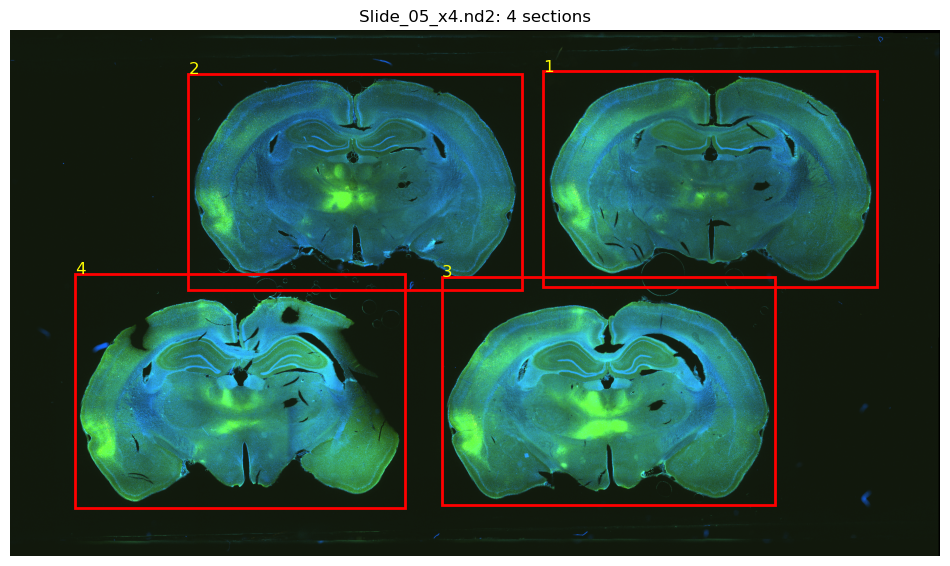

Detected sections: 4
Preview: Slide_06_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_06_x4.nd2', 'sizes': {'C': 3, 'Y': 23040, 'X': 36675}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 23040, 36675], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 23040, 'unsigned', 1, 220052, 36675, None, None, None, None, 3]}


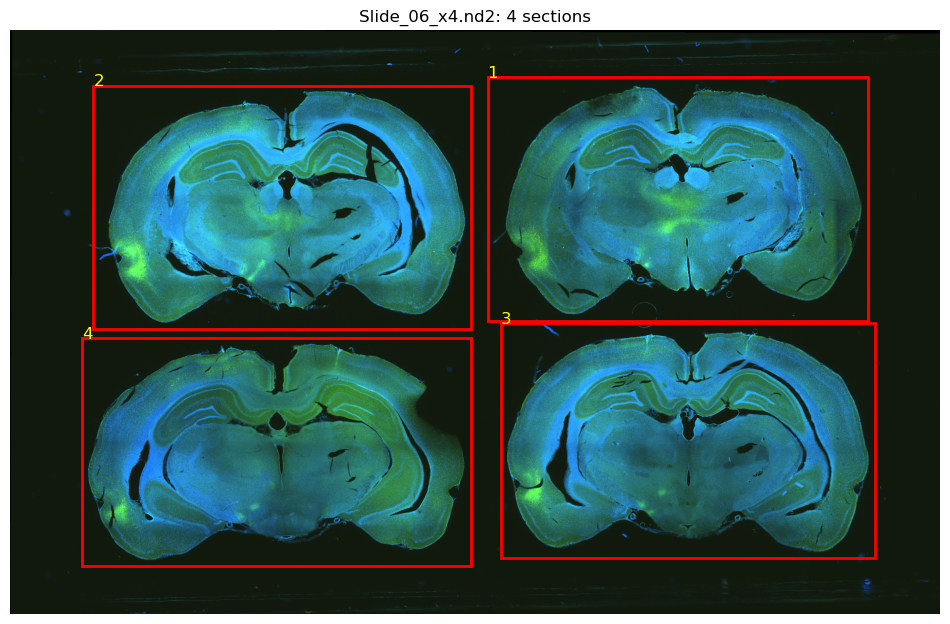

Detected sections: 4
Preview: Slide_07_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_07_x4.nd2', 'sizes': {'C': 3, 'Y': 23040, 'X': 36675}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 23040, 36675], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 23040, 'unsigned', 1, 220052, 36675, None, None, None, None, 3]}


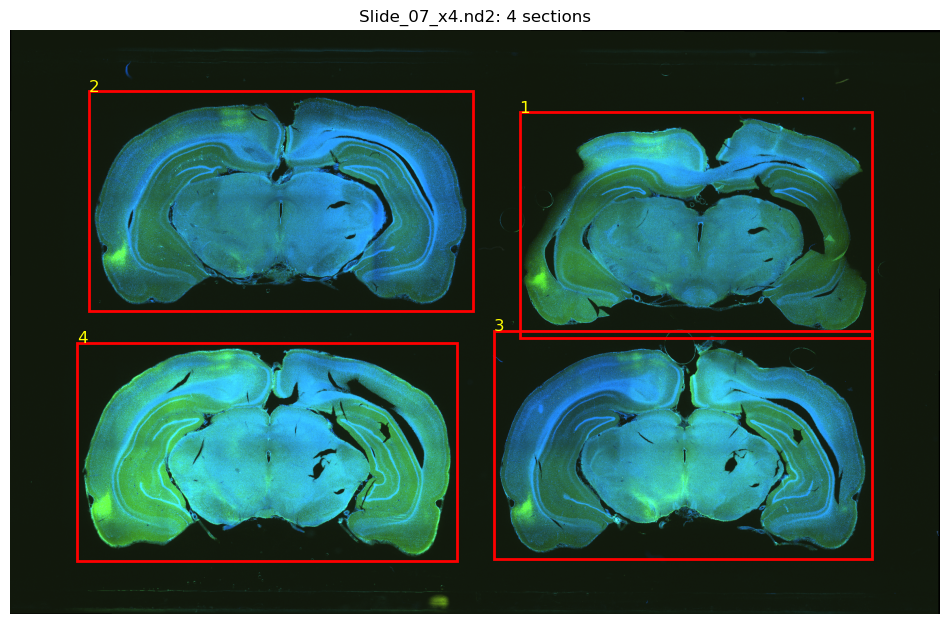

Detected sections: 4
Preview: Slide_08_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_08_x4.nd2', 'sizes': {'C': 3, 'Y': 23040, 'X': 36675}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 23040, 36675], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 23040, 'unsigned', 1, 220052, 36675, None, None, None, None, 3]}


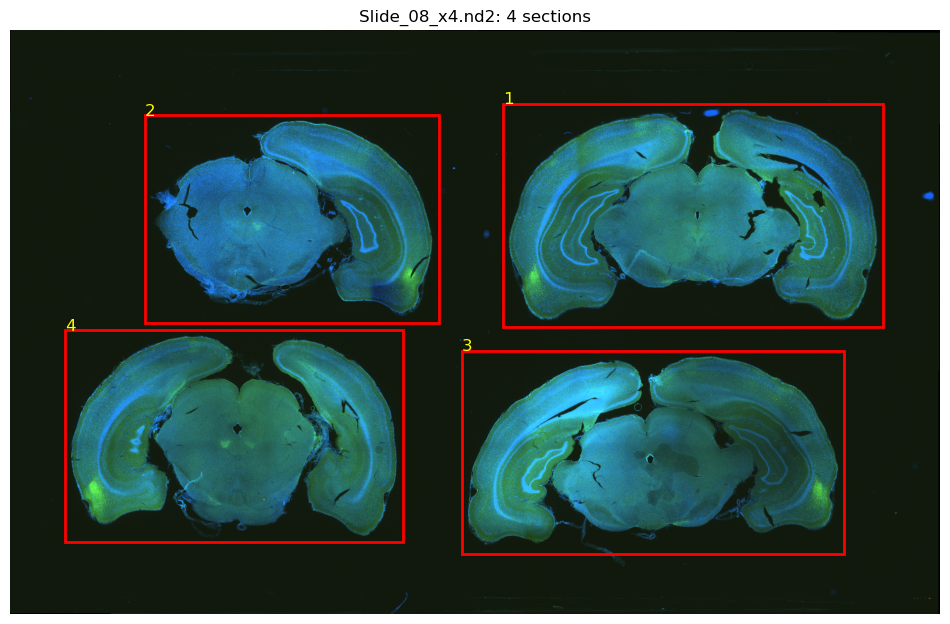

Detected sections: 4
Preview: Slide_09_x4.nd2
{'path': 'R:\\shared\\data\\AutoMaze\\RM014\\RM014_FTGO_NIKON_260610\\Slide_09_x4.nd2', 'sizes': {'C': 3, 'Y': 19800, 'X': 28575}, 'channels': [{'index': 0, 'name': 'TRITC', 'color_rgb': [3, 81, 255], 'emission_lambda_nm': 457.5, 'excitation_lambda_nm': 360.0}, {'index': 1, 'name': 'TRITC_1', 'color_rgb': [91, 255, 0], 'emission_lambda_nm': 535.0, 'excitation_lambda_nm': 480.0}, {'index': 2, 'name': 'TRITC_2', 'color_rgb': [255, 160, 0], 'emission_lambda_nm': 603.5, 'excitation_lambda_nm': 540.5}], 'shape': [3, 19800, 28575], 'dtype': 'uint16', 'is_rgb': False, 'attributes': [16, 12, 3, 19800, 'unsigned', 1, 171452, 28575, None, None, None, None, 3]}


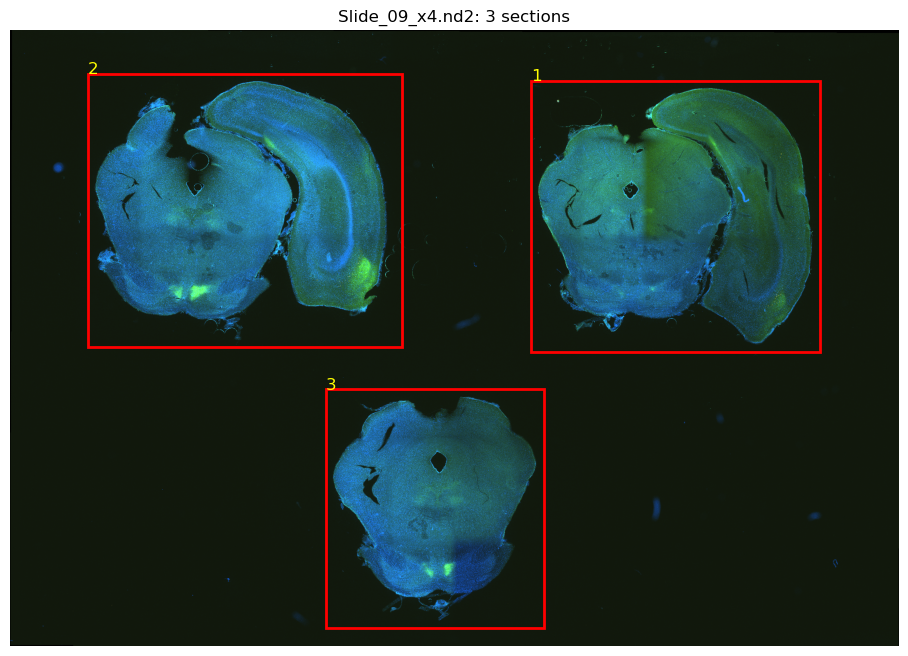

Detected sections: 3


In [5]:
preview_min_area = max(100, config.min_area // (preview_downsample ** 2))
preview_margin = max(5, config.margin // preview_downsample)
preview_opening_radius = max(0, config.opening_radius // preview_downsample)
preview_closing_iterations = max(1, config.closing_iterations // preview_downsample)

for preview_path in selected_files:
    print(f"Preview: {preview_path.name}")
    print(summarize_nd2(preview_path))
    nd2_image = read_nd2_image(
        preview_path,
        scene_index=config.scene_index,
        position_index=config.position_index,
        time_index=config.time_index,
        z_index=config.z_index,
        z_projection=config.z_projection,
        downsample=preview_downsample,
    )
    rgb = merge_channels(
        nd2_image.data,
        channel_colors=config.channel_colors,
        percentiles=config.percentiles,
        channels=config.merge_channels,
    )
    detection = detect_section_crops(
        nd2_image.data if config.mask_channel is not None else rgb,
        mask_channel=config.mask_channel,
        min_area=preview_min_area,
        margin=preview_margin,
        opening_radius=preview_opening_radius,
        closing_iterations=preview_closing_iterations,
        sort_mode=config.sort_mode,
        row_tolerance=config.row_tolerance,
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(rgb)
    for index, box in enumerate(detection.boxes, start=1):
        rect = plt.Rectangle((box.x0, box.y0), box.width, box.height, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)
        ax.text(box.x0, box.y0, str(index), color="yellow", fontsize=12)
    ax.set_title(f"{preview_path.name}: {len(detection.boxes)} sections")
    ax.set_axis_off()
    plt.show()

    print(f"Detected sections: {len(detection.boxes)}")

## 6. Run Batch Processing

In [6]:
results = process_selected_files(selected_files, output_folder, config=config)
for result in results:
    print(result.input_path.name, len(result.crop_paths), result.output_dir)
    print([path.name for path in result.crop_paths])

d:\Imaging_analysis\src\brain_section_pipeline\crop.py:92: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = morphology.binary_opening(mask, morphology.disk(opening_radius))
d:\Imaging_analysis\src\brain_section_pipeline\crop.py:92: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = morphology.binary_opening(mask, morphology.disk(opening_radius))
d:\Imaging_analysis\src\brain_section_pipeline\crop.py:92: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = morphology.binary_opening(mask, morphology.disk(opening_radius))
d:\Imaging_analysis\src\brain_section_pipeline\crop.py:92: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `ski

Slide_01_x4.nd2 6 R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610\cropped_sections\Slide_01_x4
['section001.tif', 'section002.tif', 'section003.tif', 'section004.tif', 'section005.tif', 'section006.tif']
Slide_02_x4.nd2 6 R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610\cropped_sections\Slide_02_x4
['section007.tif', 'section008.tif', 'section009.tif', 'section010.tif', 'section011.tif', 'section012.tif']
Slide_03_x4.nd2 5 R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610\cropped_sections\Slide_03_x4
['section013.tif', 'section014.tif', 'section015.tif', 'section016.tif', 'section017.tif']
Slide_04_x4.nd2 4 R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610\cropped_sections\Slide_04_x4
['section018.tif', 'section019.tif', 'section020.tif', 'section021.tif']
Slide_05_x4.nd2 4 R:\shared\data\AutoMaze\RM014\RM014_FTGO_NIKON_260610\cropped_sections\Slide_05_x4
['section022.tif', 'section023.tif', 'section024.tif', 'section025.tif']
Slide_06_x4.nd2 4 R:\shared\data\AutoMaz